In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Configurações de visualização
%matplotlib inline
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', None) # Mostrar todas as colunas

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Recarregando os dados para garantir a integridade
data_path = '../../data/processed'

df_train = pd.read_csv(os.path.join(data_path, 'ubuntu_server_dataset_train.csv'))
df_test = pd.read_csv(os.path.join(data_path, 'ubuntu_server_dataset_test.csv'))

# Limpeza inicial
df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)
df_train['service'] = df_train['service'].replace('-', 'unknown')
df_test['service'] = df_test['service'].replace('-', 'unknown')

# !! IMPORTANTE !!
# Filtrar o conjunto de treino para conter APENAS o tráfego normal
print(f"Tamanho original do treino: {len(df_train)}")
df_train_normal = df_train[df_train['label'] == 0]
print(f"Tamanho do treino após filtrar apenas dados normais: {len(df_train_normal)}")

# Definindo os conjuntos de X e y
# Treinaremos X_train_normal. O y_train não é usado no fit.
# O teste continua sendo o conjunto completo para uma avaliação realista.
X_train_normal = df_train_normal.drop(['attack_cat', 'label'], axis=1)
X_test = df_test.drop(['attack_cat', 'label'], axis=1)
y_test = df_test['label'] # Usaremos o y_test binário para avaliação

# --- PRÉ-PROCESSAMENTO ---

# Definir e ajustar o pré-processador nos dados de treino (apenas normais)
numeric_features = X_train_normal.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train_normal.select_dtypes(include=['object']).columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)
print("\nAjustando o pré-processador nos dados de treino normais...")
preprocessor.fit(X_train_normal)

# Transformar os dados de treino e teste
print("Transformando os dados...")
X_train_normal_processed = preprocessor.transform(X_train_normal)
X_test_processed = preprocessor.transform(X_test)

print("\nDados pré-processados e prontos para o Isolation Forest.")

Tamanho original do treino: 11324
Tamanho do treino após filtrar apenas dados normais: 5382

Ajustando o pré-processador nos dados de treino normais...
Transformando os dados...

Dados pré-processados e prontos para o Isolation Forest.


Taxa de contaminação calculada a partir do teste: 0.5247

Iniciando o treinamento do modelo Isolation Forest (fit nos dados normais)...
Treinamento concluído.
Realizando previsões no conjunto de teste...

--- Relatório de Classificação Binária (Isolation Forest) ---
              precision    recall  f1-score   support

  Normal (0)       0.96      0.43      0.59      2307
  Ataque (1)       0.66      0.98      0.79      2547

    accuracy                           0.72      4854
   macro avg       0.81      0.71      0.69      4854
weighted avg       0.80      0.72      0.69      4854



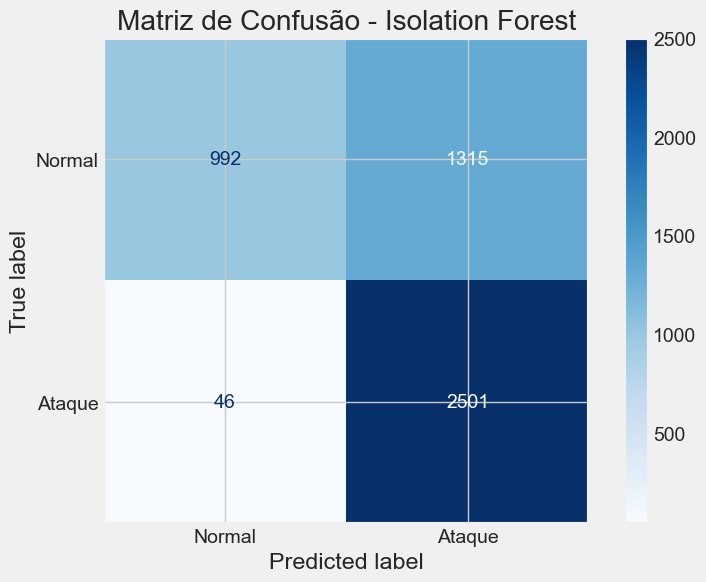

In [3]:
# --- TREINAMENTO E AVALIAÇÃO ---

# Calcular a taxa de contaminação esperada a partir do conjunto de teste
# Em um cenário real, este valor seria uma estimativa (ex: 0.01 para 1% de anomalias esperadas)
contamination_rate = y_test.value_counts(normalize=True)[1]
print(f"Taxa de contaminação calculada a partir do teste: {contamination_rate:.4f}")

# Instanciar e treinar o modelo
iso_forest = IsolationForest(
    n_estimators=150,
    contamination=float(min(contamination_rate, 0.5)),
    random_state=42,
    n_jobs=-1
)

print("\nIniciando o treinamento do modelo Isolation Forest (fit nos dados normais)...")
# O fit é feito SEM RÓTULOS (y), apenas com os dados normais processados
iso_forest.fit(X_train_normal_processed)
print("Treinamento concluído.")

# Realizar previsões no conjunto de teste completo
print("Realizando previsões no conjunto de teste...")
y_pred = iso_forest.predict(X_test_processed)

# Mapear os resultados para o formato da avaliação (0: Normal, 1: Ataque)
# O Isolation Forest retorna 1 para normal (inlier) e -1 para anomalia (outlier).
# Precisamos mapear: 1 -> 0 e -1 -> 1
y_pred_mapped = np.where(y_pred == 1, 0, 1)

# Avaliar os resultados
print("\n--- Relatório de Classificação Binária (Isolation Forest) ---")
print(classification_report(y_test, y_pred_mapped, target_names=['Normal (0)', 'Ataque (1)']))

cm = confusion_matrix(y_test, y_pred_mapped)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Ataque'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusão - Isolation Forest')
plt.savefig('confusion_matrix_multi_if.png')
plt.show()

In [4]:
try:
    # Salvar o Pré-processador
    joblib.dump(preprocessor, 'preprocessor_IF.joblib')
    print("Objeto 'preprocessor' salvo com sucesso.")
    
    # Salvar o Modelo Isolation Forest treinado
    joblib.dump(iso_forest, 'model_IF.joblib')
    print("Modelo 'iso_forest' salvo com sucesso.")

except Exception as e:
    print(f"Ocorreu um erro ao salvar os arquivos: {e}")

Objeto 'preprocessor' salvo com sucesso.
Modelo 'iso_forest' salvo com sucesso.
